In [ ]:
!pip install roboflow faiss-cpu supervision

In [ ]:
import roboflow

roboflow.login()

rf = roboflow.Roboflow()

project = rf.workspace("team-roboflow").project("coco-128")
dataset = project.version(2).download("coco")

In [ ]:
import faiss
import numpy as np
import torch
import torchvision.transforms as T
from PIL import Image
import cv2
import json
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt
import supervision as sv

dinov2_vits14 = torch.hub.load("facebookresearch/dinov2", "dinov2_vits14")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dinov2_vits14.to(device)

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


DinoVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(14, 14), stride=(14, 14))
    (norm): Identity()
  )
  (blocks): ModuleList(
    (0-11): 12 x NestedTensorBlock(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (attn): MemEffAttention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (drop_path1): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
      (ls2): LayerScale()
      (drop_path2): Identity()
    )
  )
  (n

In [ ]:
transform_image = T.Compose([
    T.ToTensor(),
    T.Resize(224),
    T.CenterCrop(224),
    T.Normalize([0.5], [0.5])])

def load_image(img: str) -> torch.Tensor:
    img = Image.open(img)
    transformed_img = transform_image(img)[:3].unsqueeze(0)
    return transformed_img

In [ ]:
def create_index(files: list, model) -> faiss.IndexFlatL2:
  index = faiss.IndexFlatL2(384)

  all_embeddings = {}

  with torch.no_grad():
    for _, file in enumerate(tqdm(files)):
      embeddings = model(load_image(file).to(device))
      embedding = embeddings[0].cpu().numpy()

      reshaped_embedding = np.array(embedding).reshape(1, -1)

      all_embeddings[file] = reshaped_embedding.tolist()
      index.add(reshaped_embedding)

  with open('all_embeddings.json', 'w') as f:
    f.write(json.dumps(all_embeddings))

  faiss.write_index(index, 'data.bin')

  return index, all_embeddings



In [ ]:
def search_index(input_index, input_embeddings, k=3) -> list:
  _, results = input_index.search(np.array(input_embeddings[0].reshape(1, -1)), k)
  return results[0]

In [ ]:
import os

cwd = os.getcwd()

ROOT_DIR = os.path.join(cwd, "COCO-128-2/train")

files = os.listdir(ROOT_DIR)
files = [os.path.join(ROOT_DIR, f) for f in files if f.lower().endswith('.jpg')]

In [ ]:
data_index, all_embeddings = create_index(files, dinov2_vits14)

  0%|          | 0/128 [00:00<?, ?it/s]

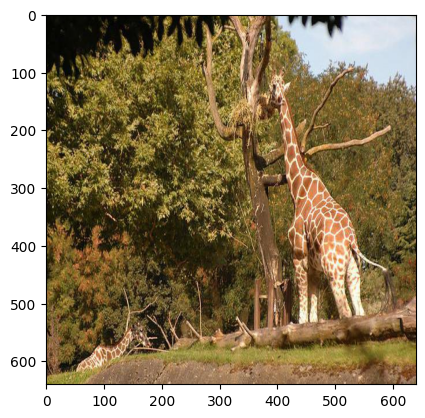

Image 0: /content/COCO-128-2/train/000000000025_jpg.rf.782fe78a513b7eeded6172306f4f502c.jpg
Image 1: /content/COCO-128-2/train/000000000072_jpg.rf.244aee5e871d00c83983a224a5eb8ed5.jpg
Image 2: /content/COCO-128-2/train/000000000144_jpg.rf.09821163c359a738ad86e72865a310dc.jpg
Image 3: /content/COCO-128-2/train/000000000136_jpg.rf.71b51a4103c3e797f62a52a9d20fddfe.jpg
Image 4: /content/COCO-128-2/train/000000000034_jpg.rf.a33e87d94b16c1112e8d9946fee784b9.jpg


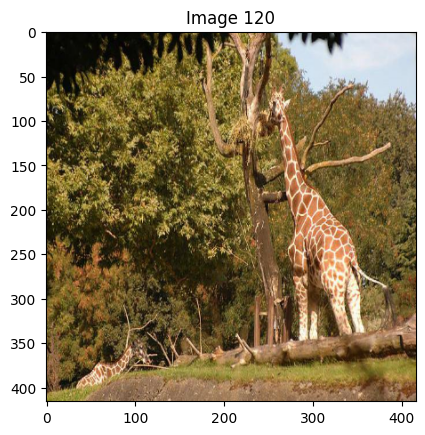

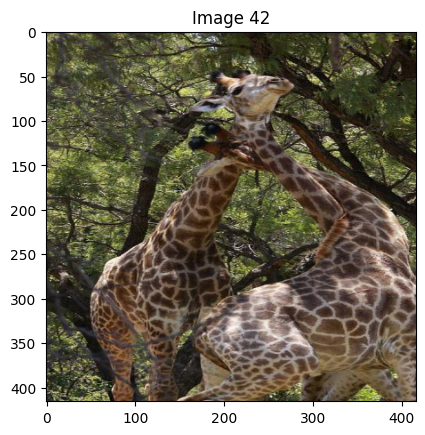

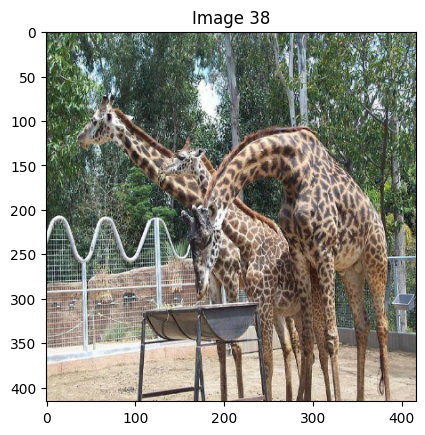

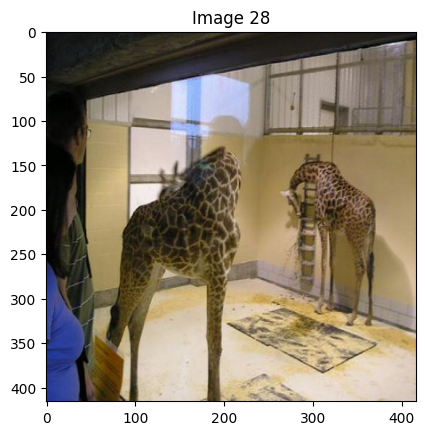

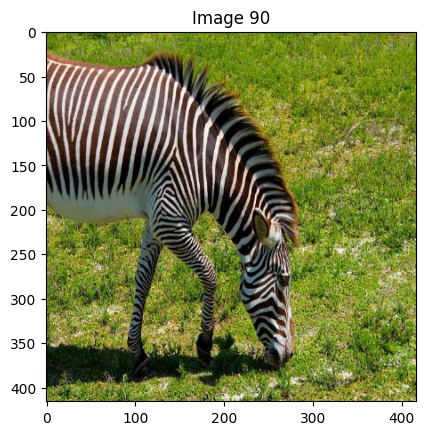

In [ ]:
input_file = "/content/COCO-128-2/test/000000000025_jpg.rf.ed74f70d3b9ede1832934740b7ac60c7.jpg"
input_img = cv2.imread(input_file)

input_img = cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB)
plt.imshow(input_img)
plt.show()

with torch.no_grad():
  embedding = dinov2_vits14(load_image(input_file).to(device))
  results = search_index(data_index, np.array(embedding[0].cpu()).reshape(1, -1), 5)

  for i, index in enumerate(results):
    print(f"Image {i}: {files[index]}")

  for i in results:
    img = cv2.resize(cv2.imread(files[i]), (416, 416))
    plt.title(f"Image {i}")
    result_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(result_img)
    plt.show()